# Markov Chain Convergence Analyzer

This project analyzes the behaviour of finite Markov chains focusing on the convergence
using linear algebra; with interest on the application in quantitative finance.


## Markov Chains

A Markov chain is a stochastic process that evolves over time between a finite set of states.

The defining property of a Markov chain is the **Markov property**:

The future state depends only on the current state, not on the sequence of past states.

Formally:

$P(X_{n+1} = j | X_n = i, X_{n-1}, ..., X_0) = P(X_{n+1} = j | X_n = i)$

---

## Transition Matrix

A Markov chain is fully described by its transition matrix P.

Each entry $P_{ij}$ represents the probability of moving from state i to state j in one step.

Properties of P:

- All entries are non-negative: $P_{ij} ≥ 0 $ 
- Each row sums to 1: $∑_j P_{ij} = 1$  
- By consequence of the definition they are square matrices

This makes P a **row-stochastic matrix**.

---

## Evolution of the System

If we represent the state of the system as a probability vector v, then the evolution is given by:

$$v_{t+1} = (v_t)(P)$$

By iterating:

$$v_n = (v_0)(P^n)$$

### Mathematical Explanation of the Evolution Equation

To understand why $v_n = v_0 P^n$ holds true, we must look at the recursive nature of Markov Chains and the fundamental properties of linear algebra. 

The evolution of a discrete-time Markov Chain is defined by the transition from state $t$ to $t+1$:
$$v_{t+1} = v_t P$$

#### 1. The Recursive Step
By applying this definition iteratively, we can find the distribution for any future time step:
* For $t=1$: $v_1 = v_0 P$
* For $t=2$: $v_2 = v_1 P$
* For $t=3$: $v_3 = v_2 P$

#### 2. The Role of Associativity
The property that allows this  is **Associativity**: $(AB)C = A(BC)$.

If we substitute $v_1$ into the equation for $v_2$:
$$v_2 = (v_0 P) P$$

By the **Associative Property**, we can regroup the terms without changing their relative order:
$$v_2 = v_0 (P P) = v_0 P^2$$

#### 3. General Proof by Induction
We can generalize this for any $n \in \mathbb{N}$ using mathematical induction:
1. **Base Case:** For $n=1$, $v_1 = v_0 P^1$ (True by definition).
2. **Inductive Step:** Assume $v_n = v_0 P^n$ is true for some $n$. Then for $n+1$:
   $$v_{n+1} = v_n P$$
   $$v_{n+1} = (v_0 P^n) P$$
   $$v_{n+1} = v_0 (P^n P) = v_0 P^{n+1}$$

#### Conclusion
The identity $v_n = v_0 P^n$ is mathematically rigorous. It allows us to compute the probability distribution at any step $n$ by simply calculating the $n$-th power of the transition matrix, provided that the vector $v_0$ remains on the left to maintain dimensional and logical consistency.

This allows us to study the long-term behavior of the system. 

Instead of tracking individual paths, We track the distribution of the system, which evolves via matrix multiplication.


### Computational Efficiency and the Power of Convergence

#### 1. Large $n$ and Matrix Diagonalization
Computing $v_n = v_0 P^n$ by repeated matrix multiplication is computationally expensive and not time efficient. To efficiently find the distribution at a specific large time step $n$, we utilize *Matrix Diagonalization*.

If $P$ is diagonalizable, it can be decomposed as $P = Q D Q^{-1}$, where $D$ is a diagonal matrix of eigenvalues and $Q$ is the matrix of corresponding eigenvectors. A fundamental property of this decomposition is:
$$P^n = (Q D Q^{-1})^n = Q D^n Q^{-1}$$

Since $D$ is diagonal, $D^n$ is simply the matrix of each eigenvalue raised to the $n$-th power ($d_{ii}^n$). This reduces the complexity of finding $P^n$ to a single decomposition and two matrix multiplications, regardless of how large $n$ is.


### Formal Definition: Eigenvalues and Eigenvectors

In order to be able to make the diagonalization process, we need to understand what are the eignvalues and eignvectors: 

Let **P** be an $n \times n$ square matrix. A scalar **$\lambda$** is called an **eigenvalue** of **P** if there exists a non-zero vector **$v$**, known as the **eigenvector**, such that the following linear equation is satisfied:

$$P v = \lambda v$$

This fundamental relationship indicates that when the linear transformation **P** is applied to the vector **$v$**, the direction of the vector remains unchanged, and it is only scaled by the factor **$\lambda$**. 

To find the eigenvalues of a matrix, we solve the **characteristic equation**, which is derived from the condition that the matrix $(P - \lambda I)$ must be singular (non-invertible):

$$\det(P - \lambda I) = 0$$

Where:
**$P$**: The transition matrix (in this context, a row-stochastic matrix).

**$\lambda$**: The eigenvalue (for stochastic matrices, the dominant eigenvalue is always 1).

**$v$**: The eigenvector associated with $\lambda$.

**$I$**: The $n \times n$ identity matrix.

### Conditions for Diagonalizability

For a transition matrix $P$ of size $n \times n$ to be diagonalizable, it must meet specific criteria. Not all square matrices can be decomposed into $P = QDQ^{-1}$. 

The fundamental conditions are:

1. **Linearly Independent Eigenvectors (Necessary and Sufficient Condition):** An $n \times n$ matrix $P$ is diagonalizable if and only if it has exactly $n$ linearly independent eigenvectors. These vectors form the basis for the columns of matrix $Q$, ensuring that $Q$ is invertible (i.e., $\det(Q) \neq 0$).

2. **Distinct Eigenvalues (Sufficient Condition):**
   If the matrix $P$ has $n$ *distinct* eigenvalues, it is guaranteed to be diagonalizable. Each distinct eigenvalue produces at least one corresponding linearly independent eigenvector.
   
**Note on Stochastic Matrices:** While many transition matrices in practical financial models are diagonalizable, it is not a strict mathematical guarantee. If a matrix has repeated eigenvalues (algebraic multiplicity > 1) and does not yield enough linearly independent eigenvectors (geometric multiplicity < algebraic multiplicity), it is called a **defective matrix** and cannot be diagonalized.

### The Diagonalization Process

To explicitly find the matrices $Q$, $D$, and $Q^{-1}$ for a given transition matrix $P$, we follow a systematic three-step linear algebra process:

**Step 1: Find the Eigenvalues ($\lambda$)**
We find the scalars $\lambda$ that satisfy the characteristic equation:
$$\det(P - \lambda I) = 0$$
where $I$ is the $n \times n$ identity matrix. Solving this polynomial yields the eigenvalues $\lambda_1, \lambda_2, \dots, \lambda_n$. For a valid row-stochastic Markov transition matrix, the largest eigenvalue will always be exactly $1$ ($\lambda_1 = 1$).

**Step 2: Find the Eigenvectors ($v$)**
For each eigenvalue $\lambda_i$ found in Step 1, we find the non-zero vector $v_i$ by solving the homogeneous system of linear equations:
$$(P - \lambda_i I)v_i = 0$$
These vectors represent the stable "directions" of the transformation.

**Step 3: Construct $Q$ and $D$**
Once we have the eigenvalues and their corresponding linearly independent eigenvectors, we assemble the matrices:
* **The Diagonal Matrix ($D$):** A matrix where the main diagonal consists of the eigenvalues $\lambda_i$, and all other entries are zero.
* **The Change of Basis Matrix ($Q$):** A matrix whose columns are the eigenvectors $v_i$. *Crucially, the order of the eigenvectors in $Q$ must exactly match the order of the eigenvalues in $D$.*
* **The Inverse Matrix ($Q^{-1}$):** Finally, we compute the inverse of $Q$ using standard matrix inversion techniques.

## 2. The Ergodic Theorem and Perron-Frobenius (Convergence)

While matrix diagonalization gives us a computational shortcut for $v_n = v_0P^n$, we need to prove that as $n \to \infty$, the state of the system actually stabilizes to a unique distribution, independent of the initial state $v_0$. This is where the **Perron-Frobenius Theorem** and the **Ergodic Theorem** provide the rigorous mathematical foundation.

### The Perron-Frobenius Theorem applied to Transition Matrices

The Perron-Frobenius Theorem characterizes the eigenvalues and eigenvectors of non-negative matrices. For a Markov transition matrix $P$ (which is non-negative and row-stochastic) that is also *irreducible*, the theorem states:

1. **Existence of a Dominant Eigenvalue:** The spectral radius (the maximum absolute value of all eigenvalues) is strictly equal to $1$. 
2. **Unique Positive Eigenvector:** There exists a unique strictly positive left eigenvector $\pi$ corresponding to this eigenvalue $\lambda = 1$, such that $\pi P = \pi$, normalized so that $\sum \pi_i = 1$.

**Mathematical Proof of $\lambda \le 1$ for Stochastic Matrices:**
We can easily prove why no eigenvalue can be greater than 1. Let $\lambda$ be any eigenvalue of $P$ with a corresponding right eigenvector $x$ (so $Px = \lambda x$). 
Let $x_i$ be the component of $x$ with the maximum absolute value ($|x_i| = \max_j |x_j|$).

Looking at the $i$-th component of the equation $Px = \lambda x$:
$$\lambda x_i = \sum_{j} P_{ij} x_j$$

Taking the absolute value on both sides:
$$|\lambda| |x_i| = \left| \sum_{j} P_{ij} x_j \right| \le \sum_{j} P_{ij} |x_j|$$

Since $|x_i|$ is the maximum absolute value, we can substitute $|x_j|$ with $|x_i|$ to establish an inequality:
$$|\lambda| |x_i| \le \sum_{j} P_{ij} |x_j| \le \sum_{j} P_{ij} |x_i| = |x_i| \sum_{j} P_{ij}$$

Because $P$ is row-stochastic, the sum of its rows is exactly 1 ($\sum_{j} P_{ij} = 1$). Therefore:
$$|\lambda| |x_i| \le |x_i| \implies |\lambda| \le 1$$

This proves that $\lambda = 1$ is the maximum possible eigenvalue (the spectral radius).

**Proof of Existence: Why $\lambda = 1$ is always an eigenvalue**

While we proved that no eigenvalue can exceed 1 in absolute value, we must also prove that $\lambda = 1$ is strictly guaranteed to exist for any valid Markov transition matrix $P$.

By definition, a transition matrix $P$ is row-stochastic, meaning the sum of the probabilities in each row must equal exactly 1:
$$\sum_{j=1}^n P_{ij} = 1 \quad \text{for all rows } i$$

Let $\mathbf{1}$ be an $n \times 1$ column vector where every entry is $1$:

$$\mathbf{1} = \begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix}$$

If we multiply the matrix $P$ by this vector $\mathbf{1}$, the operation effectively sums each row of $P$. The $i$-th component of the resulting vector is exactly the sum of the $i$-th row of $P$:
$$P \mathbf{1} = \begin{bmatrix} \sum_{j} P_{1j} \\ \sum_{j} P_{2j} \\ \vdots \\ \sum_{j} P_{nj} \end{bmatrix} = \begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix} = \mathbf{1}$$

This gives us the fundamental identity:
$$P\mathbf{1} = 1 \cdot \mathbf{1}$$

This equation perfectly matches the definition of an eigenvalue and eigenvector ($Px = \lambda x$). Since $\mathbf{1}$ is a non-zero vector, this mathematically proves that $\lambda = 1$ is strictly an eigenvalue of $P$, and the vector of all ones ($\mathbf{1}$) is its corresponding right eigenvector.

### Ergodic Markov Chains: The Sufficient Conditions

While Perron-Frobenius guarantees the existence of a stationary distribution $\pi$ for irreducible chains, it does *not* guarantee that $\lim_{n \to \infty} P^n$ converges. For convergence, we need the chain to be **Ergodic**, which requires two structural properties:

1. **Irreducibility:** Every state is reachable from every other state. Mathematically, for any states $i$ and $j$, there exists an integer $k > 0$ such that $(P^k)_{ij} > 0$. This ensures the matrix cannot be partitioned into isolated sub-systems.
2. **Aperiodicity:** The system does not return to a state in deterministic, fixed intervals. The greatest common divisor of the lengths of all paths from a state back to itself is 1.

**Why are these conditions sufficient for convergence?**

If a Markov chain is both irreducible and aperiodic, the transition matrix $P$ is called **Regular**. A fundamental property of regular matrices is that there exists some integer $m > 0$ such that all entries of $P^m$ are strictly positive.

For regular matrices, Perron-Frobenius guarantees something even stronger: **$\lambda_1 = 1$ is the *strictly* dominant eigenvalue.** All other eigenvalues have an absolute value strictly less than 1 ($|\lambda_i| < 1$ for $i \ge 2$).

Recall the diagonalization from the previous section: $P^n = QD^nQ^{-1}$.
As $n \to \infty$, the diagonal matrix $D^n$ behaves as follows:
* The entry corresponding to $\lambda_1 = 1^n$ remains $1$.
* All other entries $(\lambda_i)^n$ where $|\lambda_i| < 1$ converge to $0$.

$$\lim_{n \to \infty} D^n = \begin{bmatrix} 1 & 0 & \dots & 0 \\ 0 & 0 & \dots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \dots & 0 \end{bmatrix}$$

This algebraic decay of the non-dominant eigenvalues is the exact mechanism of convergence. The system "forgets" its initial state $v_0$ because all terms associated with the initial state are multiplied by eigenvalues that decay to zero. What remains is only the steady-state defined by the left eigenvector $\pi$, solving:
$$\pi(P - I) = 0, \quad \text{subject to } \sum \pi_i = 1$$

## Key Structural Properties

### Irreducibility

A Markov chain is **irreducible** if it is possible to reach any state from any other state (possibly in multiple steps).

This means the system is fully connected and does not split into isolated subsets.


In [46]:
#funciones
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def is_irreducible(P):
    G = nx.from_numpy_array(P > 0, create_using=nx.DiGraph)
    return nx.is_strongly_connected(G)

def plot_markov_graph(P, title="Markov Chain Transition Graph"):
    G = nx.from_numpy_array(P, create_using=nx.DiGraph)
    pos = nx.spring_layout(G)  
    plt.figure(figsize=(7, 7))
    
    # nodos (los estados)
    nx.draw(G, pos, with_labels=True, node_color="lightblue", 
            node_size=2500, font_size=14, 
            arrowsize=20, edge_color="black", connectionstyle="arc3,rad=0.1")
    
    # Extraemos las probabilidades de la matriz P para etiquetar las flechas
    # Formateamos a 2 decimales para que no se amontonen los números
    edge_labels = {(i, j): f"{P[i, j]:.2f}" for i, j in G.edges()}
    
    # Dibujamos las probabilidades sobre las flechas
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                                 font_color="black")
    
    plt.title("Markov Chain Transition Graph", fontsize=16,)
    plt.axis("off")
    plt.show()

ANÁLISIS DE CASO A: MATRIZ IRREDUCIBLE
¿Es irreducible?: True


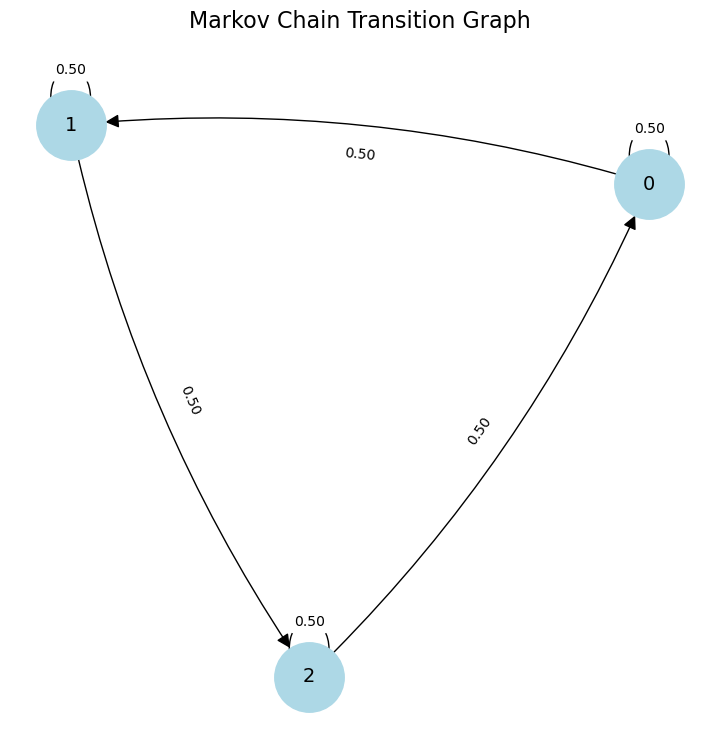

ANÁLISIS DE CASO B: MATRIZ REDUCIBLE
¿Es irreducible?: False


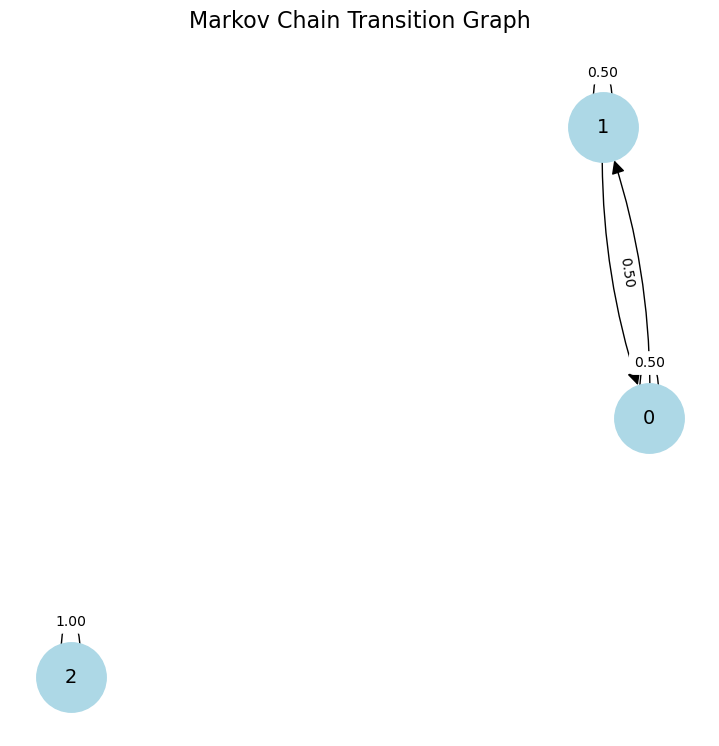

In [49]:
# 1. Matriz Irreducible (Todo se comunica)
P_irreducible = np.array([
    [0.5, 0.5, 0.0],
    [0.0, 0.5, 0.5],
    [0.5, 0.0, 0.5]
])

# 2. Matriz Reducible (Si llegas al estado 3, te quedas atrapado para siempre)
P_reducible = np.array([
    [0.5, 0.5, 0.0],
    [0.5, 0.5, 0.0],
    [0.0, 0.0, 1.0] 
])

print("ANÁLISIS DE CASO A: MATRIZ IRREDUCIBLE")
print(f"¿Es irreducible?: {is_irreducible(P_irreducible)}")
plot_markov_graph(P_irreducible, title="Caso A: Grafo Irreducible")


print("ANÁLISIS DE CASO B: MATRIZ REDUCIBLE")
print(f"¿Es irreducible?: {is_irreducible(P_reducible)}")
plot_markov_graph(P_reducible, title="Caso B: Grafo Reducible (Estado 2 es trampa)")

### Aperiodicity

A state has period k if it can only return to itself in multiples of k steps.

A Markov chain is **aperiodic** if all states have period 1.

Intuitively, this means the system does not get trapped in cycles.
